# Backpropagation for Feedforward Networks
**Course:** Artificial Neural Networks (20.IDI23) · **Mentor:** Prof. Branimir Todorović · **Author:** Elvir Muslić

This notebook produces every number and figure of the seminar paper *Backpropagation for Feedforward Networks*. The forward pass (1) and the backward recursion (5)-(7) are written by hand with PyTorch tensors in double precision; automatic differentiation appears only inside checks, next to central finite differences. Run it from the `project` folder with `.venv/bin/jupyter nbconvert --to notebook --execute --inplace backprop_project.ipynb`; the run writes `figures/` and `results.json`.

Sections: 2. Feedforward networks, 3. Backpropagation, 4. A training step by hand, 5. Experiments, 6. Conclusion.

In [1]:
import json, math, platform, time
from pathlib import Path

import matplotlib.pyplot as plt
import torch

T_START = time.perf_counter()
torch.set_num_threads(1)
torch.set_default_dtype(torch.float64)  # every tensor below is double precision
Path("figures").mkdir(exist_ok=True)
RESULTS = {"figures": [], "n_checks": 0}
plt.rcParams.update({"figure.figsize": (4.8, 2.9), "font.size": 9, "axes.labelsize": 9, "legend.fontsize": 8,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "pdf.fonttype": 42})

def check(condition, message):  # stop the run if a check fails; otherwise count it and print one line
    assert condition, f"FAILED: {message}"
    RESULTS["n_checks"] += 1
    print(f"check: {message} ✓")

def save_figure(fig, name):  # vector PDF in figures/, recorded in results.json
    fig.savefig(f"figures/{name}", bbox_inches="tight")
    RESULTS["figures"].append(name)

## 2. Feedforward networks
The layers (1), $a^{(l)} = W^{(l)} h^{(l-1)} + b^{(l)}$ and $h^{(l)} = \sigma(a^{(l)})$, are applied to all training pairs at once: the inputs are the columns of a matrix $X$, so every $h^{(l)}$ has one column per pair. The loss (2) is the mean over the columns of $\tfrac12 \lVert \hat y - y \rVert^2$. `ACTIVATIONS` holds each activation with its derivative written through the output $h = \sigma(a)$: $1 - h^2$ for $\tanh$ and $h(1 - h)$ for the logistic function.

In [2]:
ACTIVATIONS = {"tanh": (torch.tanh, lambda h: 1 - h ** 2),            # activation and its derivative, the latter
               "logistic": (torch.sigmoid, lambda h: h * (1 - h))}    # written through the output h = sigma(a)

def forward(params, acts, X):  # forward pass (1) for the columns of X; returns the layer outputs h^(0), ..., h^(L)
    outputs = [X]
    for (W, b), act in zip(params, acts):
        outputs.append(ACTIVATIONS[act][0](W @ outputs[-1] + b[:, None]))
    return outputs

def loss(y_hat, Y):  # loss (2): the mean over the columns of 0.5 * ||y_hat - y||^2
    return 0.5 * ((y_hat - Y) ** 2).sum() / Y.shape[1]

## 3. Backpropagation
`backward` is the recursion of Proposition 3.1: the output sensitivity (5), the backward step (6) through $W^{(l+1)\mathsf{T}}$ and $\sigma'$, and the parameter gradients (7) as one outer product per layer. With several columns the outer product becomes the matrix product $\delta^{(l)} h^{(l-1)\mathsf{T}}$, which sums the per-pair gradients; the division by the number of pairs in (5) turns the sum into the mean. `gradient_descent` is Algorithm 1: forward pass, backward pass and the update (3), repeated.

In [3]:
def backward(params, acts, outputs, Y):  # backward recursion (5)-(7); returns (dE/dW, dE/db) for every layer
    grads = [None] * len(params)
    delta = (outputs[-1] - Y) * ACTIVATIONS[acts[-1]][1](outputs[-1]) / Y.shape[1]  # (5), mean over the columns
    for l in reversed(range(len(params))):
        grads[l] = (delta @ outputs[l].T, delta.sum(1))                              # (7)
        if l > 0:
            delta = (params[l][0].T @ delta) * ACTIVATIONS[acts[l - 1]][1](outputs[l])  # (6)
    return grads

def gradient_descent(params, acts, X, Y, eta, steps):  # Algorithm 1; returns the loss after 0, 1, ..., steps updates
    losses = []
    for _ in range(steps):
        outputs = forward(params, acts, X)
        losses.append(loss(outputs[-1], Y).item())
        for (W, b), (dW, db) in zip(params, backward(params, acts, outputs, Y)):
            W -= eta * dW                                                            # update (3)
            b -= eta * db
    return losses + [loss(forward(params, acts, X)[-1], Y).item()]

## 4. A training step by hand
Section 4 of the paper trains the smallest nontrivial network by hand: input $x = 1$, one hidden unit and one output unit, logistic $\sigma$, loss $E = \tfrac12 (\hat y - y)^2$ with target $y = 1$, weights $W^{(1)} = W^{(2)} = 0.5$ and zero biases. The cell repeats the forward pass, the backward pass and one gradient-descent step with $\eta = 1$, compares every printed value with Table 1 of the paper, and checks the two gradients against autograd and against the central difference (4) with $\epsilon = 10^{-6}$.

In [4]:
x, y, W1, W2 = torch.tensor(1.0), torch.tensor(1.0), torch.tensor(0.5), torch.tensor(0.5)   # zero biases
a1 = W1 * x                                   # forward pass (1)
h1 = torch.sigmoid(a1)
a2 = W2 * h1
y_hat = torch.sigmoid(a2)
E = 0.5 * (y_hat - y) ** 2                    # loss (2)
delta2 = (y_hat - y) * y_hat * (1 - y_hat)    # (5)
dE_dW2 = delta2 * h1                          # (7)
delta1 = delta2 * W2 * h1 * (1 - h1)          # (6)
dE_dW1 = delta1 * x                           # (7)
PAPER = {"a1": 0.5, "h1": 0.62246, "a2": 0.31123, "y_hat": 0.57719, "E": 0.08939,   # Table 1 of the paper
         "delta2": -0.10318, "dE_dW2": -0.06423, "delta1": -0.01212, "dE_dW1": -0.01212}
values = {k: float(v) for k, v in zip(PAPER, (a1, h1, a2, y_hat, E, delta2, dE_dW2, delta1, dE_dW1))}
print("\n".join(f"{k:>7} = {v:13.9f}   paper: {PAPER[k]:9.5f}" for k, v in values.items()))
check(all(round(v, 5) == PAPER[k] for k, v in values.items()), "all nine values of Table 1, rounded to five decimals")
E_at = lambda w1, w2: 0.5 * (torch.sigmoid(w2 * torch.sigmoid(w1 * x)) - y) ** 2   # the loss as a function of the weights
W1_new, W2_new = W1 - dE_dW1, W2 - dE_dW2     # one gradient-descent step (3) with eta = 1
after = {"W1": W1_new.item(), "W2": W2_new.item(), "y_hat": torch.sigmoid(W2_new * torch.sigmoid(W1_new * x)).item(), "E": E_at(W1_new, W2_new).item()}
check(after["E"] < E, f"one step with eta = 1: W1 = {after['W1']:.6f}, W2 = {after['W2']:.6f}, y_hat = {after['y_hat']:.6f}, E falls from {E:.6f} to {after['E']:.6f}")
weights = torch.tensor([0.5, 0.5], requires_grad=True)   # autograd on the same loss, as a check
E_at(weights[0], weights[1]).backward()
auto_err = (weights.grad - torch.stack([dE_dW1, dE_dW2])).abs().max().item()
check(auto_err <= 1e-12, f"worked step = autograd, largest absolute difference {auto_err:.1e}")
eps = 1e-6                                                # central differences (4)
fd = torch.stack([E_at(0.5 + eps, 0.5) - E_at(0.5 - eps, 0.5), E_at(0.5, 0.5 + eps) - E_at(0.5, 0.5 - eps)]) / (2 * eps)
fd_err = (fd - torch.stack([dE_dW1, dE_dW2])).abs()
check(fd_err.max() <= 1e-9, f"central differences {fd[0]:.10f} and {fd[1]:.10f} differ from the worked step by {fd_err[0]:.1e} and {fd_err[1]:.1e}")
RESULTS["worked_step"] = {"values": values, "step_eta_1": after, "autograd_abs_error": auto_err,
                          "finite_difference": {"eps": eps, "values": fd.tolist(), "abs_error": fd_err.tolist()}}

     a1 =   0.500000000   paper:   0.50000
     h1 =   0.622459331   paper:   0.62246
     a2 =   0.311229666   paper:   0.31123
  y_hat =   0.577185380   paper:   0.57719
      E =   0.089386101   paper:   0.08939
 delta2 =  -0.103184702   paper:  -0.10318
 dE_dW2 =  -0.064228280   paper:  -0.06423
 delta1 =  -0.012124394   paper:  -0.01212
 dE_dW1 =  -0.012124394   paper:  -0.01212
check: all nine values of Table 1, rounded to five decimals ✓
check: one step with eta = 1: W1 = 0.512124, W2 = 0.564228, y_hat = 0.587300, E falls from 0.089386 to 0.085161 ✓
check: worked step = autograd, largest absolute difference 1.4e-17 ✓
check: central differences -0.0121243940 and -0.0642282805 differ from the worked step by 2.2e-12 and 2.9e-11 ✓


## 5. Experiments
**Gradient checks.** The recursion is compared with two independent references on a random network with layer sizes 4-8-8-3 (tanh, tanh, logistic) and one random input-target pair: autograd on the same forward pass, and the central difference (4) applied to every parameter in turn.

In [5]:
def fd_grads(params, acts, X, Y, eps=1e-6):  # central difference (4): two forward passes per parameter (checks only)
    grads = [tuple(torch.zeros_like(p) for p in pair) for pair in params]
    for p, g in zip(sum(params, ()), sum(grads, ())):   # every weight matrix and bias vector in turn
        for i in range(p.numel()):
            p0 = p.view(-1)[i].item()
            for sign in (1, -1):
                p.view(-1)[i] = p0 + sign * eps
                g.view(-1)[i] += sign * loss(forward(params, acts, X)[-1], Y).item() / (2 * eps)
            p.view(-1)[i] = p0
    return grads

def rel_diff(grads, ref):  # largest relative difference over all parameter tensors: max |g - r| / max |r|
    return max(((g - r).abs().max() / r.abs().max()).item() for g, r in zip(sum(grads, ()), sum(ref, ())))

def init_params(sizes, gen):  # weights ~ N(0, 1/fan_in), biases ~ N(0, 0.01)
    return [(torch.randn(m, n, generator=gen) / math.sqrt(n), 0.1 * torch.randn(m, generator=gen))
            for n, m in zip(sizes[:-1], sizes[1:])]

gen = torch.Generator().manual_seed(0)
params, acts = init_params([4, 8, 8, 3], gen), ["tanh", "tanh", "logistic"]
X, Y = torch.randn(4, 1, generator=gen), torch.rand(3, 1, generator=gen)
manual = backward(params, acts, forward(params, acts, X), Y)
leaves = [(W.clone().requires_grad_(), b.clone().requires_grad_()) for W, b in params]   # autograd reference
loss(forward(leaves, acts, X)[-1], Y).backward()
err_auto = rel_diff(manual, [(W.grad, b.grad) for W, b in leaves])
err_fd = rel_diff(fd_grads(params, acts, X, Y), manual)
check(err_auto <= 1e-12, f"recursion (5)-(7) = autograd on the 4-8-8-3 network, largest relative difference {err_auto:.1e}")
check(err_fd <= 1e-6, f"central differences = recursion (5)-(7) on the 4-8-8-3 network, largest relative difference {err_fd:.1e}")
RESULTS["mlp_check"] = {"seed": 0, "sizes": [4, 8, 8, 3], "activations": acts, "parameters": sum(p.numel() for p in sum(params, ())),
                        "eps": 1e-6, "rel_diff_autograd": err_auto, "rel_diff_finite_difference": err_fd}

check: recursion (5)-(7) = autograd on the 4-8-8-3 network, largest relative difference 1.9e-16 ✓
check: central differences = recursion (5)-(7) on the 4-8-8-3 network, largest relative difference 5.4e-10 ✓


**XOR.** The four inputs $(0,0), (0,1), (1,0), (1,1)$ with targets $0, 1, 1, 0$, a 2-4-1 network (tanh hidden units, logistic output), the loss (2), and plain gradient descent with $\eta = 1$ from a fixed seed. An input is classified correctly when the output lies on the same side of $0.5$ as its target.

In [6]:
def accuracy(params, acts, X, Y):  # fraction of columns whose output, thresholded at 0.5, equals the label
    return ((forward(params, acts, X)[-1] > 0.5) == (Y > 0.5)).double().mean().item()

X_xor = torch.tensor([[0.0, 0.0, 1.0, 1.0], [0.0, 1.0, 0.0, 1.0]])   # the four inputs, one per column
Y_xor = torch.tensor([[0.0, 1.0, 1.0, 0.0]])
xor_params, xor_acts = init_params([2, 4, 1], torch.Generator().manual_seed(1)), ["tanh", "logistic"]
xor_losses = gradient_descent(xor_params, xor_acts, X_xor, Y_xor, eta=1.0, steps=2000)
xor_out = forward(xor_params, xor_acts, X_xor)[-1].flatten().tolist()
check(all(xor_losses[k + 1] < xor_losses[k] for k in range(100)), "XOR: the loss decreases at every one of the first 100 steps")
check(accuracy(xor_params, xor_acts, X_xor, Y_xor) == 1.0, f"XOR solved after 2000 steps: outputs {[round(v, 3) for v in xor_out]}, loss {xor_losses[0]:.4f} -> {xor_losses[-1]:.2e}")
RESULTS["xor"] = {"seed": 1, "sizes": [2, 4, 1], "eta": 1.0, "steps": 2000, "initial_loss": xor_losses[0], "final_loss": xor_losses[-1], "outputs": xor_out}

check: XOR: the loss decreases at every one of the first 100 steps ✓
check: XOR solved after 2000 steps: outputs [0.015, 0.969, 0.969, 0.035], loss 0.1276 -> 4.17e-04 ✓


**Two moons.** Two interleaved half circles with Gaussian noise of standard deviation $0.1$: 200 training and 200 test points from a fixed seed, a 2-16-1 network (tanh hidden units, logistic output), full-batch gradient descent with $\eta = 1$ for 5000 steps.

In [7]:
def make_moons(n, noise, gen):  # n points on two interleaved half circles plus Gaussian noise: X is 2 x n, Y is 1 x n
    t = math.pi * torch.rand(n // 2, generator=gen)
    X = torch.cat([torch.stack([torch.cos(t), torch.sin(t)]), torch.stack([1 - torch.cos(t), 0.5 - torch.sin(t)])], dim=1)
    return X + noise * torch.randn(2, n, generator=gen), torch.cat([torch.zeros(1, n // 2), torch.ones(1, n // 2)], dim=1)

gen = torch.Generator().manual_seed(2)
X_train, Y_train = make_moons(200, 0.1, gen)
X_test, Y_test = make_moons(200, 0.1, gen)
moon_params, moon_acts = init_params([2, 16, 1], gen), ["tanh", "logistic"]
moon_losses = gradient_descent(moon_params, moon_acts, X_train, Y_train, eta=1.0, steps=5000)
train_acc, test_acc = accuracy(moon_params, moon_acts, X_train, Y_train), accuracy(moon_params, moon_acts, X_test, Y_test)
check(train_acc == 1.0, f"two moons: training accuracy {train_acc:.3f} after 5000 steps, loss {moon_losses[0]:.4f} -> {moon_losses[-1]:.4f}")
check(test_acc >= 0.95, f"two moons: test accuracy {test_acc:.3f} on 200 fresh points")
RESULTS["moons"] = {"seed": 2, "sizes": [2, 16, 1], "n_train": 200, "n_test": 200, "noise": 0.1, "eta": 1.0, "steps": 5000,
                    "initial_loss": moon_losses[0], "final_loss": moon_losses[-1], "train_accuracy": train_acc, "test_accuracy": test_acc}

check: two moons: training accuracy 1.000 after 5000 steps, loss 0.1136 -> 0.0010 ✓
check: two moons: test accuracy 0.995 on 200 fresh points ✓


**Figures.** Figure 1 of the paper: the training loss per step for XOR and the moons. Figure 2: the training and test points of the moons with the decision boundary, the curve on which the network output equals $0.5$.

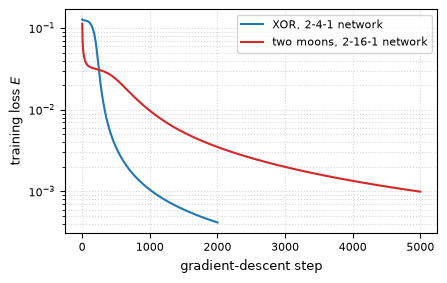

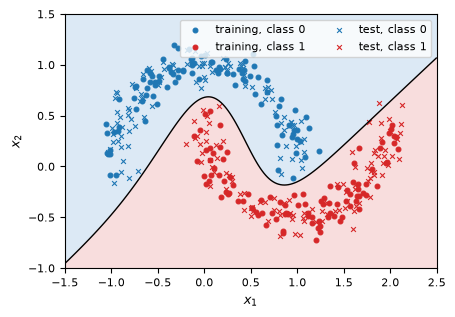

In [8]:
fig, ax = plt.subplots()
ax.semilogy(xor_losses, color="tab:blue", label="XOR, 2-4-1 network")
ax.semilogy(moon_losses, color="tab:red", label="two moons, 2-16-1 network")
ax.set(xlabel="gradient-descent step", ylabel="training loss $E$")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
save_figure(fig, "training_loss.pdf")

fig, ax = plt.subplots(figsize=(4.8, 3.3))
g1, g2 = torch.meshgrid(torch.linspace(-1.5, 2.5, 201), torch.linspace(-1.0, 1.5, 201), indexing="xy")
Z = forward(moon_params, moon_acts, torch.stack([g1.flatten(), g2.flatten()]))[-1].reshape(g1.shape)
ax.contourf(g1, g2, Z, levels=[0.0, 0.5, 1.0], colors=["#dce9f5", "#f8dddd"])
ax.contour(g1, g2, Z, levels=[0.5], colors="k", linewidths=1.0)
for X_, Y_, marker, name in ((X_train, Y_train, "o", "training"), (X_test, Y_test, "x", "test")):
    for cls, color in ((0, "tab:blue"), (1, "tab:red")):
        ax.scatter(*X_[:, Y_[0] == cls], marker=marker, s=12, color=color, linewidths=0.8, label=f"{name}, class {cls}")
ax.set(xlabel="$x_1$", ylabel="$x_2$")
ax.legend(loc="upper right", ncol=2)
save_figure(fig, "moons_boundary.pdf")

In [9]:
# every number quoted in the paper and the README, hand-copied with the rounding used there
QUOTED = {"table_5dp": [0.5, 0.62246, 0.31123, 0.57719, 0.08939, -0.10318, -0.06423, -0.01212, -0.01212],
          "table_9dp": [0.5, 0.622459331, 0.311229666, 0.57718538, 0.089386101, -0.103184702, -0.06422828, -0.012124394, -0.012124394],
          "step_6dp": [0.512124, 0.564228, 0.5873, 0.085161], "E_before_6dp": 0.089386, "autograd_abs_2sig": 1.4e-17,
          "fd_W1_10dp": -0.012124394, "fd_err_2sig": [2.2e-12, 2.9e-11], "n_params": 139, "mlp_autograd_2sig": 1.9e-16,
          "mlp_fd_2sig": 5.4e-10, "xor_steps": 2000, "xor_loss": [0.128, 4.2e-4], "xor_outputs_2dp": [0.01, 0.97, 0.97, 0.03],
          "moons_steps": 5000, "moons_loss_4dp": [0.1136, 0.0010], "train_acc": 1.0, "test_acc_3dp": 0.995, "test_errors": 1, "n_checks": 11}
W, M, XO, MO = RESULTS["worked_step"], RESULTS["mlp_check"], RESULTS["xor"], RESULTS["moons"]
sig2 = lambda v: float(f"{v:.1e}")   # two significant digits
computed = {"table_5dp": [round(v, 5) for v in W["values"].values()], "table_9dp": [round(v, 9) for v in W["values"].values()],
            "step_6dp": [round(W["step_eta_1"][k], 6) for k in ("W1", "W2", "y_hat", "E")], "E_before_6dp": round(W["values"]["E"], 6),
            "autograd_abs_2sig": sig2(W["autograd_abs_error"]), "fd_W1_10dp": round(W["finite_difference"]["values"][0], 10),
            "fd_err_2sig": [sig2(v) for v in W["finite_difference"]["abs_error"]], "n_params": M["parameters"],
            "mlp_autograd_2sig": sig2(M["rel_diff_autograd"]), "mlp_fd_2sig": sig2(M["rel_diff_finite_difference"]),
            "xor_steps": XO["steps"], "xor_loss": [round(XO["initial_loss"], 3), sig2(XO["final_loss"])],
            "xor_outputs_2dp": [round(v, 2) for v in XO["outputs"]], "moons_steps": MO["steps"],
            "moons_loss_4dp": [round(MO["initial_loss"], 4), round(MO["final_loss"], 4)], "train_acc": MO["train_accuracy"],
            "test_acc_3dp": round(MO["test_accuracy"], 3), "test_errors": round(MO["n_test"] * (1 - MO["test_accuracy"])),
            "n_checks": RESULTS["n_checks"] + 1}   # + 1 for the check below
check(computed == QUOTED, f"all {len(QUOTED)} numbers quoted in the paper and the README match this run")
RESULTS.update(versions={"python": platform.python_version(), "torch": torch.__version__, "matplotlib": plt.matplotlib.__version__},
               runtime_seconds=round(time.perf_counter() - T_START, 2))
Path("results.json").write_text(json.dumps(RESULTS, indent=2, ensure_ascii=False) + "\n")
print(f"results.json written ({len(RESULTS['figures'])} figures in figures/, {RESULTS['n_checks']} checks); runtime {RESULTS['runtime_seconds']} s")

check: all 19 numbers quoted in the paper and the README match this run ✓
results.json written (2 figures in figures/, 11 checks); runtime 1.31 s


## 6. Conclusion
- **Worked step (Section 4).** All nine values of Table 1 are reproduced, correctly rounded to five decimals, including $\partial E / \partial W^{(2)} = -0.06423$ and $\partial E / \partial W^{(1)} = -0.01212$. Autograd agrees with the hand-written gradients to $1.4 \cdot 10^{-17}$; the central difference $-0.0121243940$ for $W^{(1)}$ differs by $2.2 \cdot 10^{-12}$, the one for $W^{(2)}$ by $2.9 \cdot 10^{-11}$. One step with $\eta = 1$ lowers the loss from $0.089386$ to $0.085161$.
- **Deeper network.** On the 4-8-8-3 network (139 parameters) the recursion (5)-(7) matches autograd to a relative difference of $1.9 \cdot 10^{-16}$ and central differences to $5.4 \cdot 10^{-10}$.
- **XOR.** Gradient descent with $\eta = 1$ lowers the loss from $0.128$ to $4.2 \cdot 10^{-4}$ in 2000 steps, and the loss decreases at every one of the first 100 steps. The outputs $0.01, 0.97, 0.97, 0.03$ classify all four inputs correctly.
- **Two moons.** 5000 steps lower the loss from $0.1136$ to $0.0010$. Training accuracy $1.0$, test accuracy $0.995$: one error in 200 test points.
- **Checks.** 11 checks guard the run; the last one compares every number quoted in the paper and the README with this run.